In [1]:
import gc
from pathlib import Path

import h3
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from functools import lru_cache


### Load files

In [ ]:
INPUT_FILES = {
    "origin": "../combinedrids/originlatlon_hashed_rid.parquet",
    "destination": "../combinedrids/destlatlon_hashed_rid.parquet",
    # "uniqueo": "../combinedrids/unique_rider_per_hexagon.parquet",
    # "uniqued": "../combinedrids/unique_rider_per_hexagon.parquet",
}

LAT_LON_COLS = {
    "origin": ("trip_start_lat", "trip_start_lon"),
    "destination": ("trip_end_lat", "trip_end_lon"),
    # "uniqueo": ("trip_start_lat", "trip_start_lon"),
    # "uniqued": ("trip_end_lat", "trip_end_lon"),
}

RESOLUTIONS = range(8, 9)
METRICS = ["count", "log_count"]

# Spatial crop (Bangalore example)
LON_MIN, LON_MAX = 77.0, 78.0
LAT_MIN, LAT_MAX = 12.5, 13.5

OUTPUT_DIR = Path("origin_destin_plots")
OUTPUT_DIR.mkdir(exist_ok=True)


In [3]:
@lru_cache(maxsize=500_000)
def h3_to_polygon_cached(h):
    boundary = h3.cell_to_boundary(h)
    return Polygon([(lng, lat) for lat, lng in boundary])


In [4]:
def build_h3_counts(df, lat_col, lon_col, res):
    valid = df[lat_col].notna() & df[lon_col].notna()
    print(len(df), len(df[valid]))
    lat = df.loc[valid, lat_col].values
    lon = df.loc[valid, lon_col].values

    h3_index = [
        h3.latlng_to_cell(la, lo, res)
        for la, lo in zip(lat, lon)
    ]

    print(len)

    counts = (
        pd.Series(h3_index)
        .value_counts()
        .rename_axis("h3")
        .reset_index(name="count")
    )


    print(f"Total hexagons at resolution {res}: {len(counts)}")
    print("   Max trips in one cell:", counts["count"].median())

    counts["log_count"] = np.log1p(counts["count"])
    return counts


In [5]:
def attach_geometry(counts_df):
    counts_df = counts_df.copy()
    counts_df["geometry"] = counts_df["h3"].map(h3_to_polygon_cached)

    return gpd.GeoDataFrame(
        counts_df,
        geometry="geometry",
        crs="EPSG:4326"
    )


In [6]:
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def plot_gdf(gdf, column, out_path, boundary_gdf=None):
    fig, ax = plt.subplots(figsize=(20, 20))

    # ---- Main plot (NO legend here) ----
    gdf.plot(
        column=column,
        cmap="Reds",
        linewidth=1,
        edgecolor="black",
        ax=ax,

    )

    # ---- Bangalore outline ----
    if boundary_gdf is not None:
        boundary_gdf.boundary.plot(
            ax=ax,
            color="black",
            linewidth=0.01
        )

    # ---- Custom colorbar ----
    vmin = gdf[column].min()
    vmax = gdf[column].max()

    norm = Normalize(vmin=vmin, vmax=vmax)
    sm = ScalarMappable(norm=norm, cmap="Reds")
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax,
        fraction=0.03,   # ↓ size of colorbar
        pad=0.01
    )

    cbar.ax.tick_params(labelsize=18)   # ↑ tick font size
    cbar.set_label(column, fontsize=21, weight="bold")

    # ---- Final layout ----
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)


In [7]:
bangalore_boundary = gpd.read_file(
    "bangalore_boundary.geojson"
).to_crs("EPSG:4326")

bangalore_boundary = bangalore_boundary.buffer(0)


In [ ]:
from statistics import mode


def main():
    # for mode in ["origin", "destination", "uniqueo", "uniqued"]:
    for mode in ["origin", "destination"]:
        print(f"\nProcessing {mode.upper()}")

        df = pd.read_parquet(INPUT_FILES[mode], engine="pyarrow")
        lat_col, lon_col = LAT_LON_COLS[mode]

        for res in RESOLUTIONS:
            print(f"  Resolution {res}")

            counts = build_h3_counts(df, lat_col, lon_col, res)

            # # Geometry + spatial crop
            gdf = attach_geometry(counts)
            gdf = gdf.cx[LON_MIN:LON_MAX, LAT_MIN:LAT_MAX]

            print(f"   Geometry attached: {len(gdf)} hexagons")

            # THIS is what makes it look like Bangalore
            gdf = gpd.clip(gdf, bangalore_boundary)

            print(f"   After clipping to Bangalore boundary:")
            print("   Raw points:", len(df))
            print("   Unique H3 cells:", len(gdf))
            print("   Max trips in one cell:", gdf["count"].max())
            print("   Sum of trips in all cells:", gdf["count"].sum())

            for metric in METRICS:
                out_path = Path(OUTPUT_DIR) / mode / metric
                out_path.mkdir(parents=True, exist_ok=True)
                out_file = out_path / f"{mode}_res{res}_{metric}.png"
                # plot_gdf(gdf, metric, out_file)
                plot_gdf(gdf, metric, out_file, boundary_gdf=bangalore_boundary)

            # HARD cleanup (important)
            del gdf, counts
            gc.collect()


if __name__ == "__main__":
    main()



Processing ORIGIN
  Resolution 8
1652099 1652099
<built-in function len>
Total hexagons at resolution 8: 2253
   Max trips in one cell: 50.0
   Geometry attached: 2240 hexagons
   After clipping to Bangalore boundary:
   Raw points: 1652099
   Unique H3 cells: 1020
   Max trips in one cell: 18006
   Sum of trips in all cells: 1602105

Processing DESTINATION
  Resolution 8
1652099 1652099
<built-in function len>
Total hexagons at resolution 8: 2705
   Max trips in one cell: 23.0
   Geometry attached: 2690 hexagons
   After clipping to Bangalore boundary:
   Raw points: 1652099
   Unique H3 cells: 1023
   Max trips in one cell: 17907
   Sum of trips in all cells: 1599044


In [16]:
import numpy as np
import matplotlib.pyplot as plt

def plot_trip_distribution(gdf, out_file):
    counts = gdf["count"].values

    bins = np.logspace(
        np.log10(max(1, counts.min())),
        np.log10(counts.max()),
        40
    )

    plt.figure(figsize=(6, 4))
    plt.hist(counts, bins=bins)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Trips per H3 hex")
    plt.ylabel("Number of hexagons")
    plt.title("Trip distribution across hexagons")
    plt.tight_layout()
    plt.savefig(out_file, dpi=200)
    plt.close()


In [17]:
def trip_cdf(gdf):
    counts = np.sort(gdf["count"].values)
    cum_trips = np.cumsum(counts)
    total = cum_trips[-1]

    cdf = cum_trips / total
    return counts, cdf


In [18]:
def top_k_stats(gdf, k_frac=0.1):
    g = gdf.sort_values("count", ascending=False)
    k = int(len(g) * k_frac)

    top_trips = g.head(k)["count"].sum()
    total_trips = g["count"].sum()

    return {
        "hex_fraction": k_frac,
        "trip_fraction": top_trips / total_trips
    }




In [20]:
def ensure_parent(path: Path) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    return path




Processing ORIGIN
  Resolution 8
1652099 1652099
<built-in function len>
Total hexagons at resolution 8: 2253
   Max trips in one cell: 50.0
Trip count distribution (per hex):
  Min: 1
  P25: 297.5
  Median: 866.0
  P75: 2157.5
  P90: 4016.300000000001
  P95: 5198.9
  Max: 18006


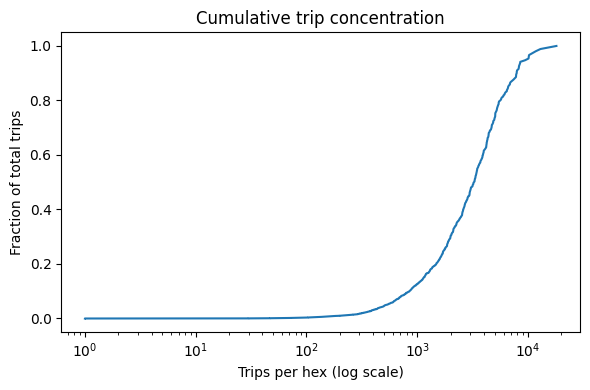

{'hex_fraction': 0.1, 'trip_fraction': np.float64(0.3823469747613296)}
{'hex_fraction': 0.05, 'trip_fraction': np.float64(0.23669734505541148)}

Processing DESTINATION
  Resolution 8
1652099 1652099
<built-in function len>
Total hexagons at resolution 8: 2705
   Max trips in one cell: 23.0
Trip count distribution (per hex):
  Min: 1
  P25: 282.5
  Median: 823.0
  P75: 2195.5
  P90: 3986.6000000000017
  P95: 5349.099999999999
  Max: 17907


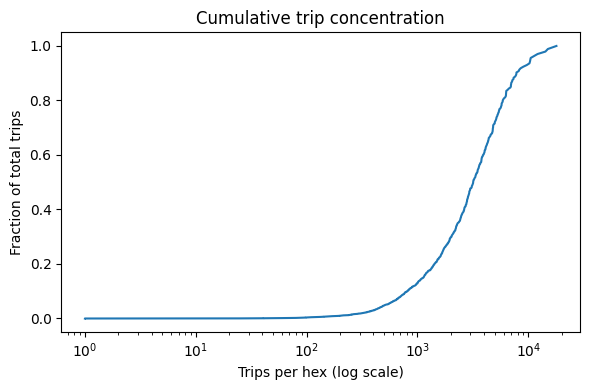

{'hex_fraction': 0.1, 'trip_fraction': np.float64(0.3928397217337359)}
{'hex_fraction': 0.05, 'trip_fraction': np.float64(0.24571368892913517)}


In [21]:
def main2():
    for mode in ["origin", "destination"]:
        print(f"\nProcessing {mode.upper()}")

        df = pd.read_parquet(INPUT_FILES[mode], engine="pyarrow")
        lat_col, lon_col = LAT_LON_COLS[mode]

        for res in RESOLUTIONS:
            print(f"  Resolution {res}")

            counts = build_h3_counts(df, lat_col, lon_col, res)

            # # Geometry + spatial crop
            gdf = attach_geometry(counts)
            gdf = gdf.cx[LON_MIN:LON_MAX, LAT_MIN:LAT_MAX]

            # THIS is what makes it look like Bangalore
            gdf = gpd.clip(gdf, bangalore_boundary)

            
            counts_arr = gdf["count"].values
            
            print("Trip count distribution (per hex):")
            print("  Min:", counts_arr.min())
            print("  P25:", np.percentile(counts_arr, 25))
            print("  Median:", np.median(counts_arr))
            print("  P75:", np.percentile(counts_arr, 75))
            print("  P90:", np.percentile(counts_arr, 90))
            print("  P95:", np.percentile(counts_arr, 95))
            print("  Max:", counts_arr.max())

            plot_trip_distribution(
            gdf,
            ensure_parent(OUTPUT_DIR /"trip" / f"{mode}_res{res}_trip_distribution.png")
            )

            counts, cdf = trip_cdf(gdf)

            plt.figure(figsize=(6, 4))
            plt.plot(counts, cdf)
            plt.xscale("log")
            plt.xlabel("Trips per hex (log scale)")
            plt.ylabel("Fraction of total trips")
            plt.title("Cumulative trip concentration")
            plt.grid(False)
            plt.tight_layout()
            plt.show()


            print(top_k_stats(gdf, 0.10))  # top 10% hexes
            print(top_k_stats(gdf, 0.05))  # top 5% hexes

            # HARD cleanup (important)
            del gdf, counts
            gc.collect()


if __name__ == "__main__":
    main2()


In [22]:
def plot_bangalore_only(boundary_gdf, out_path):
    fig, ax = plt.subplots(figsize=(20, 20))

    boundary_gdf.boundary.plot(
        ax=ax,
        color="black",
        linewidth=1.2
    )

    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)


In [23]:
# Save Bangalore-only reference image
plot_bangalore_only(
    bangalore_boundary,
    OUTPUT_DIR / "bangalore_boundary_only.png"
)


In [24]:
def plot_bangalore_city_and_wards(boundary_gdf, out_path):
    fig, ax = plt.subplots(figsize=(20, 20))

    # Ward boundaries (light)
    boundary_gdf.boundary.plot(
        ax=ax,
        color="black",
        linewidth=1,
        alpha=0.6
    )

    # # Dissolved city outline (bold)
    # boundary_gdf.dissolve().boundary.plot(
    #     ax=ax,
    #     color="black",
    #     linewidth=1.5
    # )

    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)


In [25]:
# plot_bangalore_city_and_wards(
#     bangalore_boundary,
#     OUTPUT_DIR / "bangalore_city_wards.png"
# )


In [26]:
wards_gdf = (
    gpd.read_file("bangalore_boundary.geojson")
    .to_crs("EPSG:4326")
)

# Fix invalid geometries (CRITICAL)
wards_gdf["geometry"] = wards_gdf.geometry.buffer(0)


In [27]:
def make_points_gdf(df, lat_col, lon_col):
    valid = df[lat_col].notna() & df[lon_col].notna()

    return gpd.GeoDataFrame(
        df.loc[valid],
        geometry=gpd.points_from_xy(
            df.loc[valid, lon_col],
            df.loc[valid, lat_col]
        ),
        crs="EPSG:4326"
    )


In [28]:
def aggregate_by_ward(points_gdf, wards_gdf):
    joined = gpd.sjoin(
        points_gdf,
        wards_gdf,
        how="inner",
        predicate="within"
    )

    counts = (
        joined.groupby(wards_gdf.index.name or "index_right")
        .size()
        .rename("count")
        .reset_index()
    )

    wards_out = wards_gdf.merge(
        counts,
        left_index=True,
        right_on=counts.columns[0],
        how="left"
    )

    wards_out["count"] = wards_out["count"].fillna(0).astype(int)
    wards_out["log_count"] = np.log1p(wards_out["count"])

    return wards_out


In [29]:
def plot_ward_choropleth(gdf, column, out_path):
    fig, ax = plt.subplots(figsize=(20, 20))

    gdf.plot(
        column=column,
        cmap="Reds",
        linewidth=0.6,
        edgecolor="black",
        legend=True,
        ax=ax
    )

    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)


# def plot_ward_choropleth(gdf, column, out_path):
#     fig, ax = plt.subplots(figsize=(20, 20))

#     # Ward choropleth
#     gdf.plot(
#         column=column,
#         cmap="Reds",
#         linewidth=0.6,
#         edgecolor="black",
#         legend=True,
#         ax=ax
#     )

#     # 🔴 Mark the given point
#     ax.scatter(
#         77.70483201467022,   # longitude (x)
#         13.232487024642113,  # latitude (y)
#         color="blue",
#         s=200,               # marker size
#         marker="x",
#         linewidths=3,
#         zorder=10            # ensure it stays on top
#     )

#     ax.set_axis_off()
#     plt.tight_layout()
#     plt.savefig(out_path, dpi=300, bbox_inches="tight")
#     plt.close(fig)


In [30]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

def plot_ward_choropleth(gdf, column, out_path):
    fig, ax = plt.subplots(figsize=(20, 20))

    # Plot wards
    gdf.plot(
        column=column,
        cmap="Reds",
        linewidth=0.6,
        edgecolor="black",
        legend=True,
        ax=ax
    )

    # ---- Create point GeoDataFrame ----
    point = gpd.GeoDataFrame(
        geometry=[Point(77.70483201467022, 13.232487024642113)],
        crs="EPSG:4326"   # WGS84
    )

    # ---- Reproject point to match Bangalore CRS ----
    if gdf.crs != point.crs:
        point = point.to_crs(gdf.crs)

    # ---- Clip point to Bangalore boundary ----
    clipped_point = gpd.clip(point, gdf)

    # ---- Plot only if point is inside Bangalore ----
    if not clipped_point.empty:
        clipped_point.plot(
            ax=ax,
            color="blue",
            markersize=2000,
            marker="x",
            linewidth=30,
            zorder=100
        )

    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)


In [31]:
# def plot_ward_choropleth(gdf, column, out_path):
#     fig, ax = plt.subplots(figsize=(20, 20))

#     # Ward choropleth
#     gdf.plot(
#         column=column,
#         cmap="Reds",
#         linewidth=0.6,
#         edgecolor="black",
#         legend=True,
#         ax=ax
#     )

#     # 🔒 LOCK AXIS LIMITS TO WARD GEOMETRY
#     minx, miny, maxx, maxy = gdf.total_bounds
#     ax.set_xlim(minx, maxx)
#     ax.set_ylim(miny, maxy)

#     # 📍 Correct point (lon, lat)
#     lon = 77.70483201467022
#     lat = 13.232487024642113

#     ax.scatter(
#         lon,
#         lat,
#         color="blue",
#         s=200,
#         marker="x",
#         linewidths=3,
#         zorder=10
#     )

#     ax.set_axis_off()
#     plt.tight_layout()
#     plt.savefig(out_path, dpi=300, bbox_inches="tight")
#     plt.close(fig)


In [33]:
def main3():

    print("Starting visualization process")
    for mode in ["origin", "destination"]:
        print(f"\nProcessing {mode.upper()}")

        df = pd.read_parquet(INPUT_FILES[mode], engine="pyarrow")
        lat_col, lon_col = LAT_LON_COLS[mode]

        points_gdf = make_points_gdf(df, lat_col, lon_col)

        wards_with_counts = aggregate_by_ward(
            points_gdf,
            wards_gdf
        )

        print("Total trips:", len(points_gdf))
        print("Wards:", len(wards_with_counts))
        print("Max trips in ward:", wards_with_counts["count"].max())

        for metric in ["count", "log_count"]:
            out_file = ensure_parent(OUTPUT_DIR / f"{mode}" / "ward" / f"{mode}_wards_{metric}.png")
            plot_ward_choropleth(
                wards_with_counts,
                metric,
                out_file
            )

        del points_gdf, wards_with_counts
        gc.collect()

if __name__ == "__main__":
    main3()

Starting visualization process

Processing ORIGIN
Total trips: 1652099
Wards: 243
Max trips in ward: 34975

Processing DESTINATION
Total trips: 1652099
Wards: 243
Max trips in ward: 41207


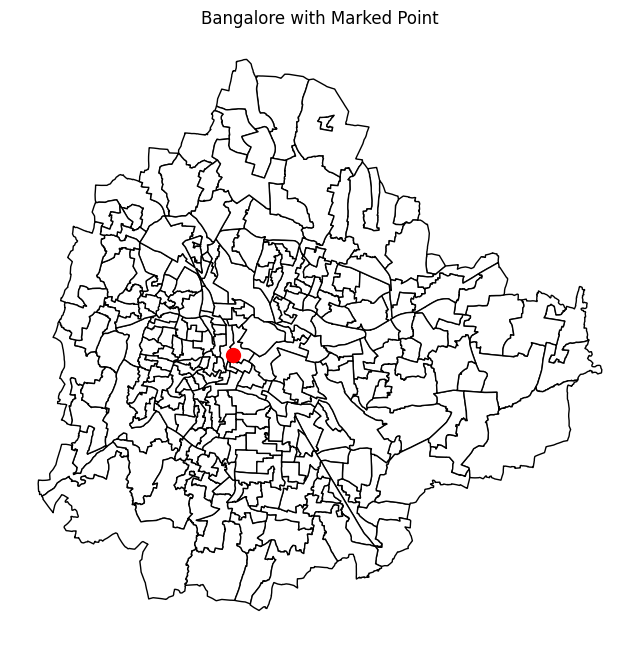

In [34]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Load Bangalore boundary
bangalore = gpd.read_file("bangalore_boundary.geojson")

# Point you want to mark (example: MG Road, Bangalore)
lat = 12.976681322846185
lon = 77.57203275668451

point = gpd.GeoDataFrame(
    geometry=[Point(lon, lat)],
    crs="EPSG:4326"
)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
bangalore.plot(ax=ax, color="white", edgecolor="black")
point.plot(ax=ax, color="red", markersize=100)

ax.set_title("Bangalore with Marked Point")
ax.axis("off")

plt.show()
